In [57]:
import os
import zipfile
import cv2
from PIL import Image, ImageOps, ImageEnhance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Replace 'football_clubs.zip' with your actual zip file name if it's different
zip_path = '/content/Clubs 100.zip'
extract_dir = 'football_clubs_dataset'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Get a list of all image paths (assuming they are directly inside the extracted folder)
image_files = [f for f in os.listdir(extract_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_paths = [os.path.join(extract_dir, f) for f in image_files]

print(f"Total images found: {len(image_paths)}")

Total images found: 100


In [58]:
metadata = []

for path in image_paths:
    img = cv2.imread(path)
    if img is not None:
        h, w, c = img.shape
        filename=os.path.basename(path)
        metadata.append({'Filename': filename, 'Height': h, 'Width': w, 'Channels': c})

# Store in a Pandas DataFrame (Table)
df_metadata = pd.DataFrame(metadata)
print("Image Metadata Table:")
display(df_metadata)

Image Metadata Table:


,Filename,Height,Width,Channels
0,hamburg.png,400,400,3
1,udinese.png,400,400,3
2,barcelona.png,150,150,3
3,lazio.png,400,400,3
4,stuttgart.png,400,400,3
...,...,...,...,...
95,hertha-bsc-berlin.png,400,400,3
96,wolves.png,140,140,3
97,bayern.png,400,400,3
98,watford.png,140,140,3


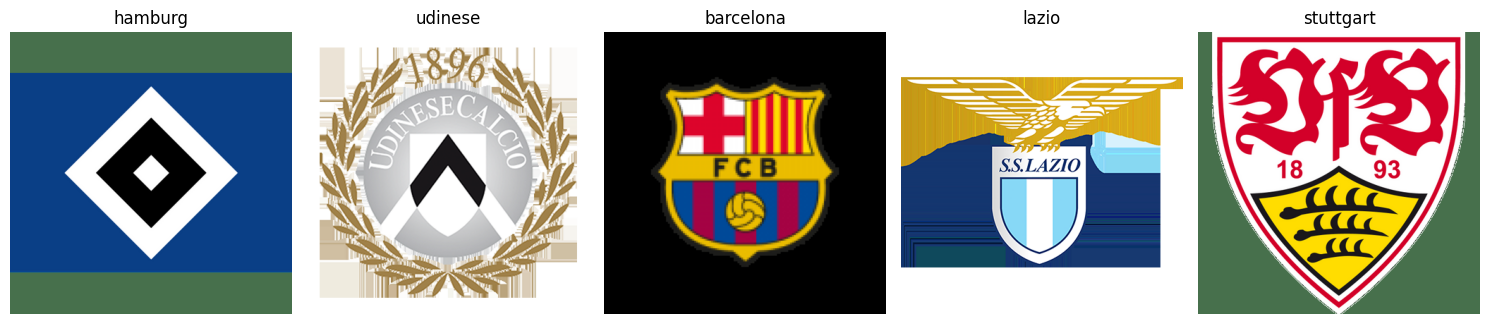

In [59]:
plt.figure(figsize=(15, 5))
for i in range(min(5, len(image_paths))):
    img_bgr = cv2.imread(image_paths[i])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # OpenCV reads in BGR, convert to RGB for plotting


    # Extract the filename from the path (e.g., 'dataset/Arsenal.jpg' -> 'Arsenal.jpg')
    filename = os.path.basename(image_paths[i])

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_rgb)
    plt.title(filename.split(".")[0])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [60]:
# TASK 5: Normalize pixel values from 0-255 to 0-1
# We typically normalize the RGB image for deep learning models
img_normalized = img_rgb.astype('float32') / 255.0
array_slice = img_normalized[0:10, 0:10, 0]

# Convert it to a Pandas DataFrame
df_array = pd.DataFrame(array_slice)
# 'display()' renders the nice table in Colab
df_array



,0,1,2,3,4,5,6,7,8,9
0,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
1,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
2,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
3,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
4,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
5,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
6,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
7,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
8,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431
9,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431,0.278431


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


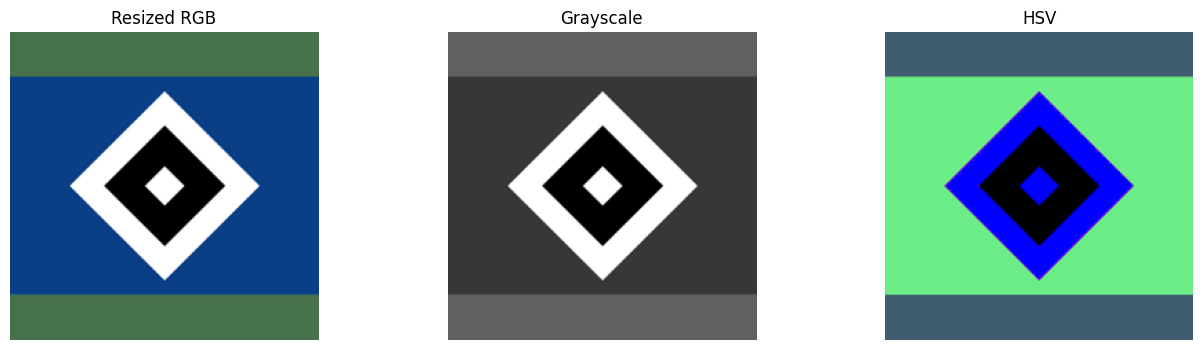

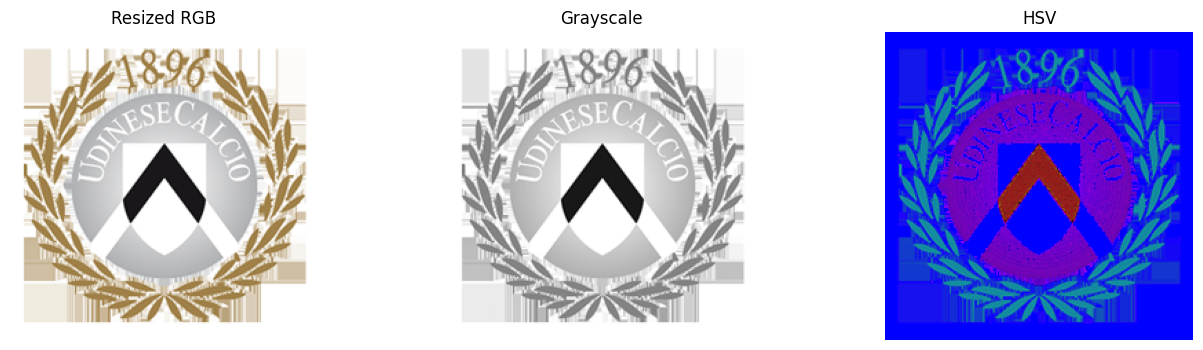

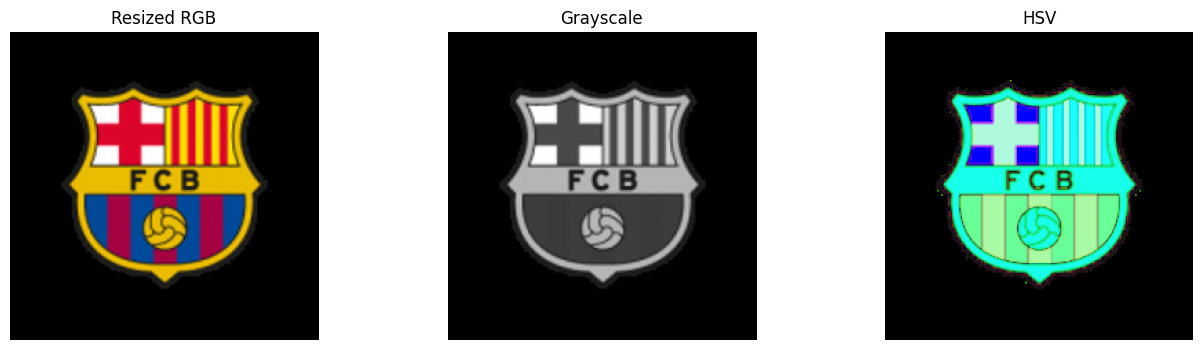

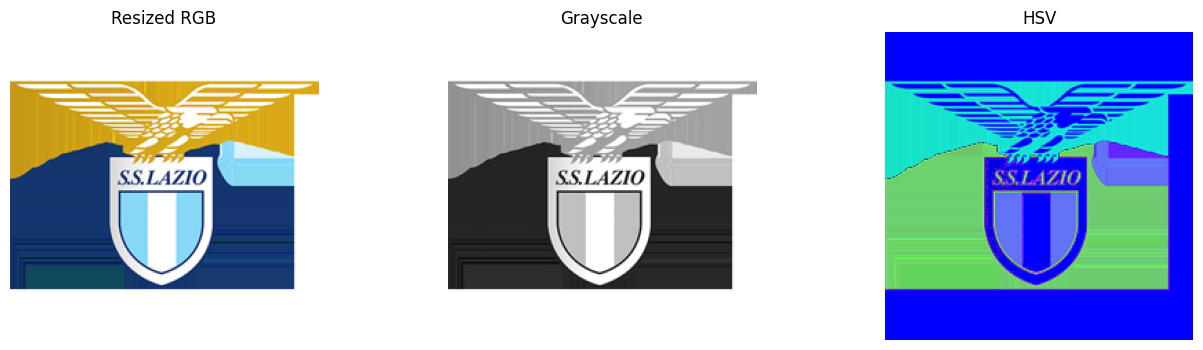

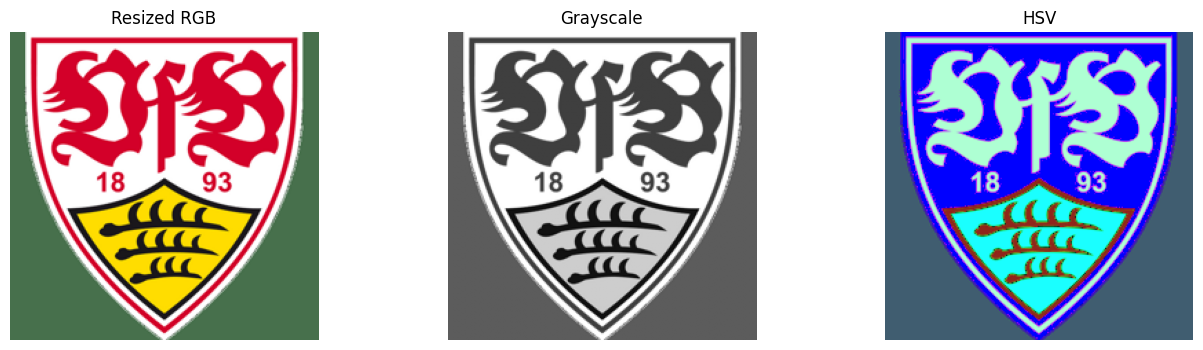

In [61]:
# ---Create a reusable preprocess_image() function ---
def preprocess_image(image_path):
    """
    Complete preprocessing pipeline (Tasks 3, 4, 5, 9, 10).
    Takes an image path and returns a dictionary containing all processed versions.
    """

    # Load image using PIL and ensure it is RGB
    pil_img = Image.open(image_path).convert('RGB')


    # --- TASK 3: Resize to 224x224 ---
    pil_resized = pil_img.resize((224, 224))

    # --- TASK 9: Data Augmentations ---
    augmentations={
        'flipped':ImageOps.mirror(pil_resized),
        'rotated':pil_resized.rotate(30),
        'brighter':ImageEnhance.Brightness(pil_resized).enhance(1.5),
        'contrast':ImageEnhance.Contrast(pil_resized).enhance(2.0)
    }

    # --- Convert to NumPy/OpenCV format for remaining tasks ---
    img_rgb = np.array(pil_resized)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    # --- TASK 4: Color Conversions ---
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # --- TASK 5: Normalization (0 to 1) ---
    img_normalized = img_rgb.astype('float32') / 255.0

    # Return everything structured
    return {
        'resized_rgb': img_rgb,
        'grayscale': img_gray,
        'hsv': img_hsv,
        'augmentations': augmentations,
        'normalized_array': img_normalized # <--- Your 0-1 array is stored here
    }

# Test the function on the first image and visualize the color conversions
for i in range(5):
  sample_processed = preprocess_image(image_paths[i])

  fig, axes = plt.subplots(1, 3, figsize=(16, 4))
  axes[0].imshow(sample_processed['resized_rgb']); axes[0].set_title("Resized RGB")
  axes[1].imshow(sample_processed['grayscale'], cmap='gray'); axes[1].set_title("Grayscale")
  axes[2].imshow(sample_processed['hsv']); axes[2].set_title("HSV")


  for ax in axes:
    ax.axis('off')
plt.show()

In [62]:
test_image_path = os.path.join(input_dir, image_files[0])

# Run the entire pipeline in one line
processed_data=preprocess_image(test_image_path)

# Output the raw array representation for the Colab cell
processed_data['normalized_array']

array([[[0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        ...,
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923]],

       [[0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        ...,
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923]],

       [[0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        ...,
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923]],

       ...,

       [[0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0.4392157 , 0.29803923],
        [0.2784314 , 0

Generating and displaying augmentations for the first 5 images...


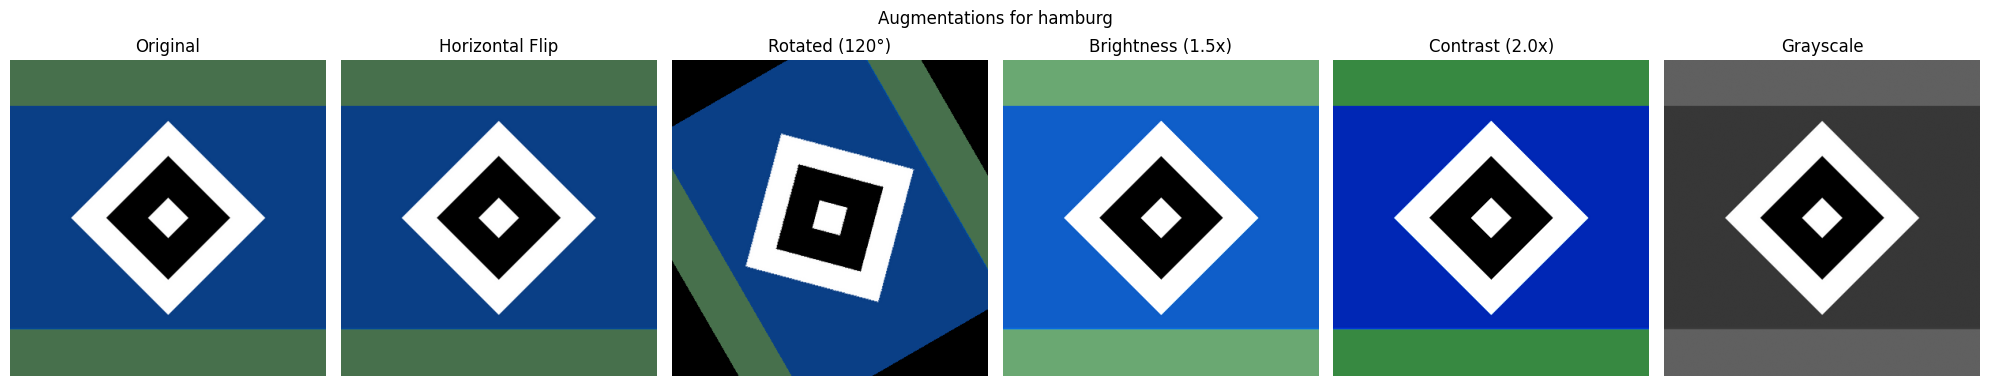

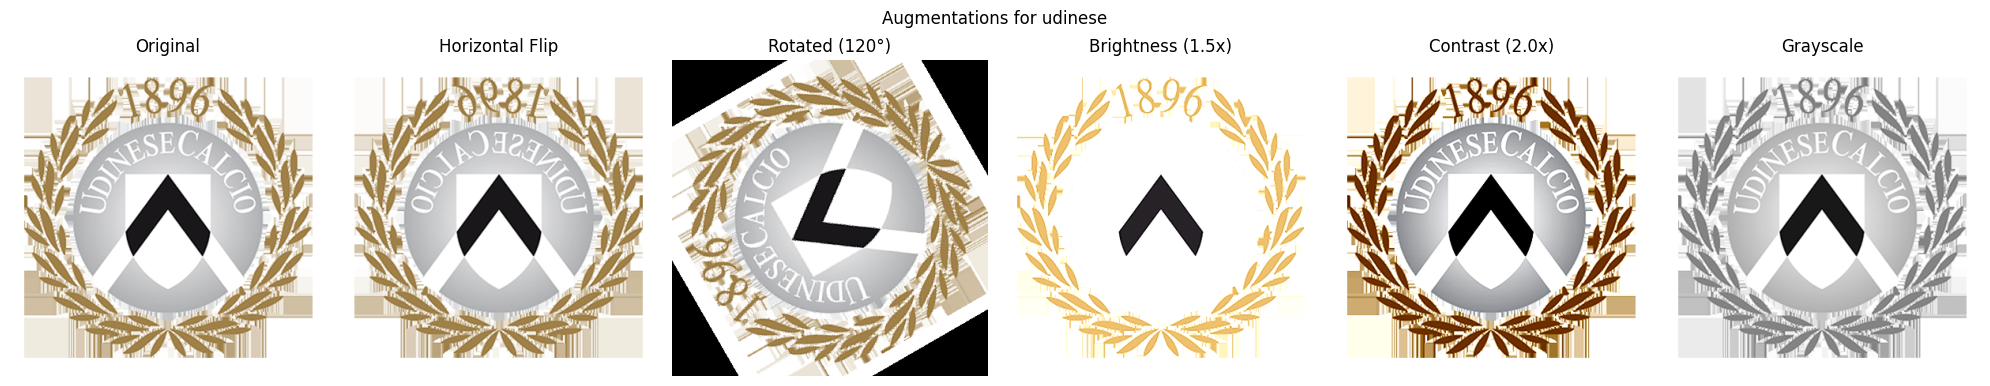

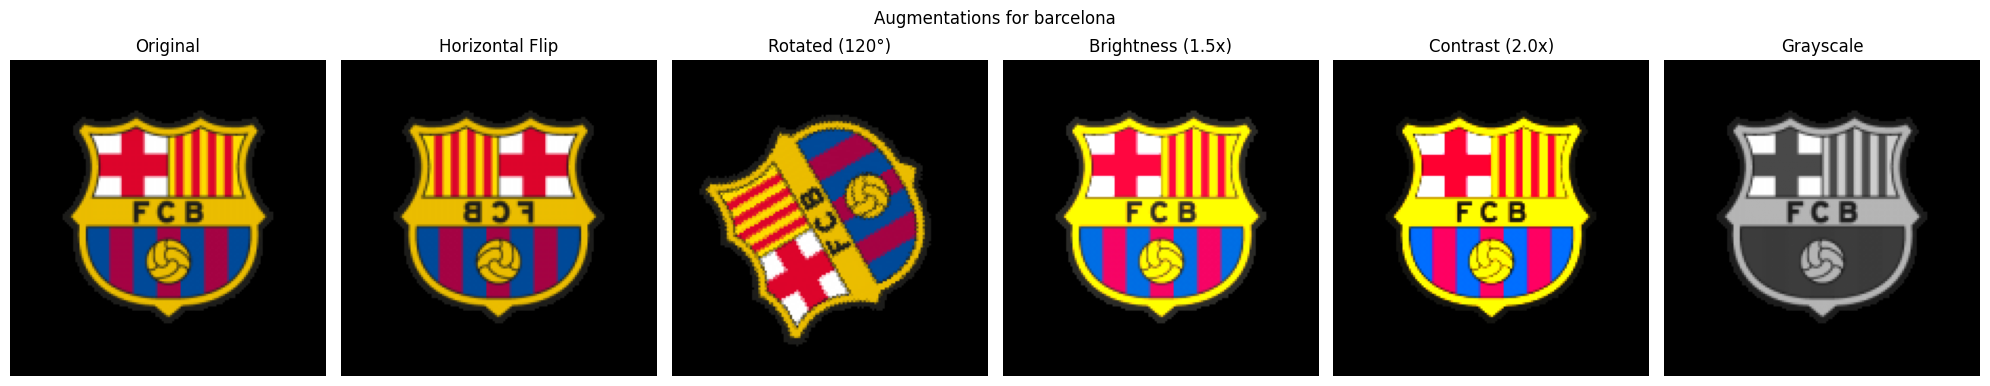

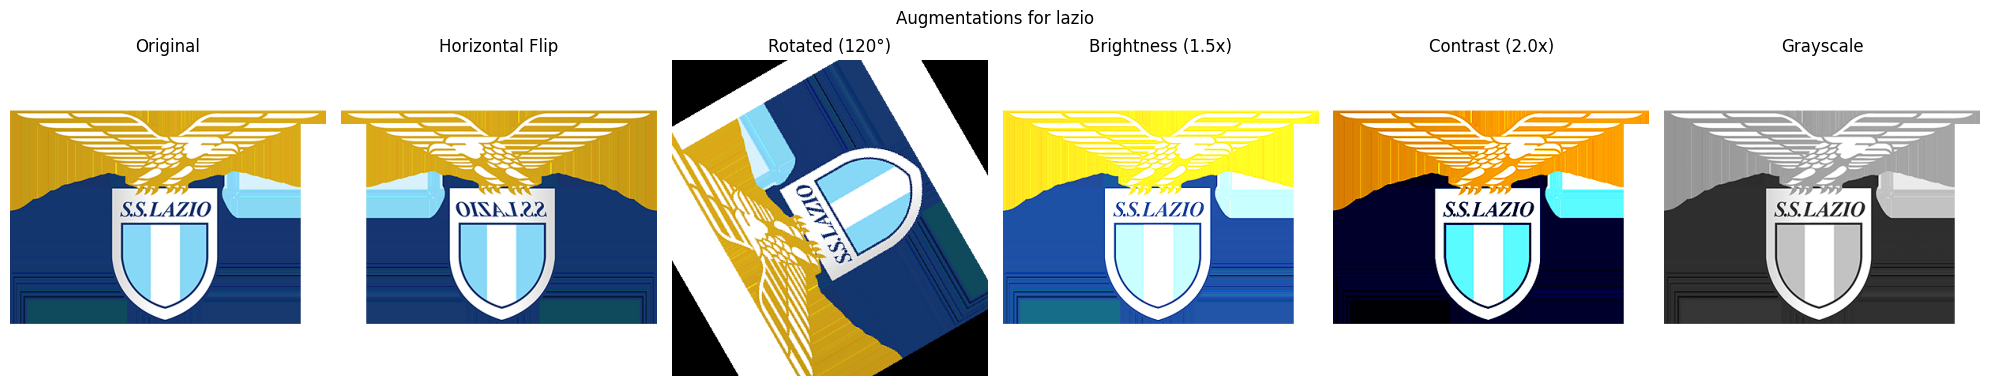

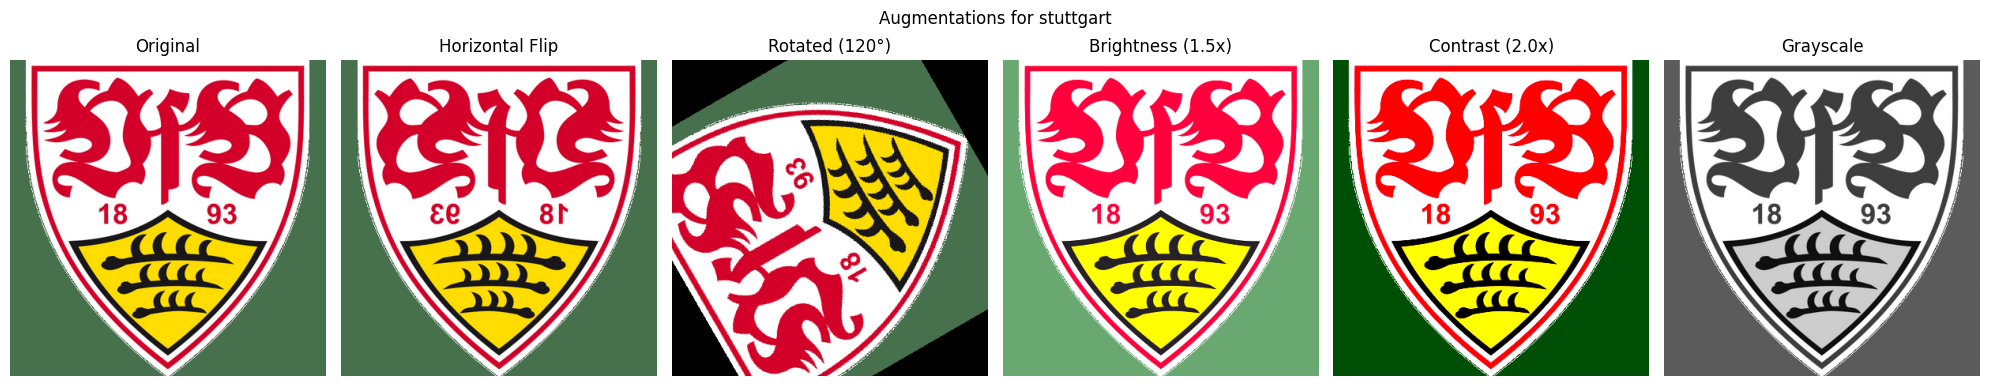

In [63]:
input_dir='football_clubs_dataset'

# Fetch image files
image_files=[f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Generating and displaying augmentations for the first 5 images...")

# Strictly processing only the first 5 images
for filename in image_files[:5]:
    img_path=os.path.join(input_dir, filename)


    # Load the original image
    image=Image.open(img_path).convert('RGB')

    # Generate the augmentations in memory
    flipped=ImageOps.mirror(image)
    rotated=image.rotate(120)
    brighter=ImageEnhance.Brightness(image).enhance(1.5)
    contrast=ImageEnhance.Contrast(image).enhance(2.0)
    grayscale=ImageOps.grayscale(image)

    # --- Display Logic ---
    # Create a figure with 1 row and 6 columns
    fig,axes=plt.subplots(1, 6, figsize=(20, 4))

    # Plot Original
    axes[0].imshow(image)
    axes[0].set_title("Original")

    # Plot Flipped
    axes[1].imshow(flipped)
    axes[1].set_title("Horizontal Flip")

    # Plot Rotated
    axes[2].imshow(rotated)
    axes[2].set_title("Rotated (120°)")

    # Plot Brightness
    axes[3].imshow(brighter)
    axes[3].set_title("Brightness (1.5x)")

    # Plot Contrast
    axes[4].imshow(contrast)
    axes[4].set_title("Contrast (2.0x)")

    # Plot Grayscale
    axes[5].imshow(grayscale, cmap='gray')
    axes[5].set_title("Grayscale")

    # Turn off axis lines and labels for all subplots to make it clean
    for ax in axes:
        ax.axis('off')

    plt.suptitle(f"Augmentations for {filename.split(".")[0]}")
    plt.tight_layout()
    plt.show()